This notebook will create the basic "counting and types" figure which also will show the plot-type accuracy plots.

In [165]:
main_llm_dir = '/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/'

# low-tier
low_dirs_to_use = ['chatgpt_api/', 'gemini/', 'claude_haiku/']

# mid-to-high tier
midHigh_dirs_to_use = ['chatgpt_api_highR_lowVerbose/', 'claude_haiku_thinking_maxT8000/', 'chatgpt_api_highR_lowVerbose_mini/']


# full baseline data stored
dir_jsons = '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/qa_jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/jcdl_followup/paper_figures/'


In [166]:
from sys import path
path.append('../')

import matplotlib.pyplot as plt
from importlib import reload
from copy import deepcopy
import numpy as np
import pandas as pd
import seaborn as sns
import fastwer
from matplotlib.patches import Patch


import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks

reload(utils.results_plotting_utils)
from utils.results_plotting_utils import add_kde_contours
from utils.parse_lmm_output_utils import get_lmm_gt

import utils.replace_names_utils
reload(utils.replace_names_utils)
from utils.replace_names_utils import replace_names

dirs_to_use = deepcopy(low_dirs_to_use)
dirs_to_use.extend(midHigh_dirs_to_use)

In [167]:
def make_question_tags():
    df_question_tags = {}
    for t in ['tag', 'question', 'Level', 'Type']:
        df_question_tags[t] = []
    return df_question_tags



In [168]:
import utils.results_plotting_utils
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import get_dirs_names_files

dirnames, dirs, files_parsed = get_dirs_names_files(main_llm_dir, 
        dirs_to_use, 
        replace_names = replace_names,
        verbose=True)

DIRS:
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet_maxtoken8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_mini
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_sonnet
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_old
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku_thinking_maxT8000
/Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api_highR_lowVerbose_mini

ONLY USED DIRNAMES, DIRS
GPT ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/chatgpt_api/
Gemini ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/gemini/
Claude ,  /Users/jnaiman/Dropbox/jcdl_followup/LMM_outputs/claude_haiku

In [169]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files, fix_aspect

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=False, use_explanation=True)
print("!!!!!!!! DONE LOADING !!!!!!!!!!!")

[ERROR]: different types of values, could not fix:
  GT: 52.99653059346398 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -9.285323670614062 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 105.2835618283954 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 28761.352807168292 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 855749.1277505575 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 4.181899993866321 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 112.86780638500066 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: 

<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\!'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\m'


[ERROR]: different types of values, could not fix:
  GT: 394989.4245753032 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 1.3292471202919642 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: -4.737678118300518 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -4.626523655992868 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 2.6204138473535163 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: -263.69179358271674 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"median color": ""}

[ERROR]: different types of values, could not fix:
  GT: 14809.219467762321 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean co

<unknown>:1: SyntaxWarning: invalid escape sequence '\_'


[ERROR]: different types of values, could not fix:
  GT: 166.763705553173 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.534922356901159 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 14.097384175999514 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean y": ""}

[ERROR]: different types of values, could not fix:
  GT: -61.790358773008236 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 56.70596563290669 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: different types of values, could not fix:
  GT: 1385.3350403983563 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean x": ""}

[ERROR]: different types of values, could not fix:
  GT: 5.572388681886037 <class 'float'>
  LLM:  <class 'str'>
  raw LLM: {"mean color": ""}

[ERROR]: 

<unknown>:1: SyntaxWarning: invalid escape sequence '\c'
<unknown>:1: SyntaxWarning: invalid escape sequence '\d'
<unknown>:1: SyntaxWarning: invalid escape sequence '\D'
<unknown>:1: SyntaxWarning: invalid escape sequence '\G'
<unknown>:1: SyntaxWarning: invalid escape sequence '\G'
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\ '
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\g'
<unknown>:1: SyntaxWarning: invalid escape sequence '\s'
<unknown>:1: SyntaxWarning: invalid escape sequence '\e'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: invalid escape sequence '\P'
<unknown>:1: SyntaxWarning: invalid escape sequence '\p'
<unknown>:1: SyntaxWarning: inv

[ERROR]: different types of values, could not fix:
  GT: -249349.01704986204 <class 'float'>
  LLM: Unable to determine from visible labels <class 'str'>
  raw LLM: {"maximum color": "Unable to determine from visible labels"}

[ERROR]: different types of values, could not fix:
  GT: -513215.2147431419 <class 'float'>
  LLM: null <class 'str'>
  raw LLM: {"mean color": "null"}

[ERROR]: different types of values, could not fix:
  GT: -857456.5832552586 <class 'float'>
  LLM: Unable to determine from image <class 'str'>
  raw LLM: {"minimum color": "Unable to determine from image"}



<unknown>:3: SyntaxWarning: invalid escape sequence '\o'
<unknown>:2: SyntaxWarning: invalid escape sequence '\o'


[ERROR]: different types of values, could not fix:
  GT: 130.54067743578003 <class 'float'>
  LLM: Unable to determine <class 'str'>
  raw LLM: {"mean color": "Unable to determine"}

!!!!!!!! DONE LOADING !!!!!!!!!!!


In [170]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type,Explanation
0,Picture_000090_qa,NaN,None,How many panels are in this figure?,False,GPT,gpt-5.4-nano-2026-03-17,"{'nrows': 1, 'ncols': 1}","{'nrows': 1, 'ncols': 1}",Level 1,Figure-level questions,{'explanation': 'The figure shows a single bar...
1,Picture_000090_qa,NaN,None,What is the plot style used in this figure?,False,GPT,gpt-5.4-nano-2026-03-17,{'plot style': 'ggplot'},{'plot style': 'seaborn-v0_8-muted'},Level 1,Figure-level questions,{'explanation': 'The figure has the characteri...
2,Picture_000090_qa,NaN,None,What is the colormap that was used in this fig...,False,GPT,gpt-5.4-nano-2026-03-17,{'colormap': 'rainbow'},{'colormap': 'RdYlGn_r'},Level 1,Figure-level questions,{'explanation': 'The bars transition from gree...
3,Picture_000090_qa,NaN,None,What is the aspect ratio of this figure?,False,GPT,gpt-5.4-nano-2026-03-17,{'aspect ratio': 1.28},{'aspect ratio': 1.4234785880384306},Level 1,Figure-level questions,{'explanation': 'The image shows a plot area t...
4,Picture_000090_qa,NaN,None,What are the titles for each figure panel?,False,GPT,gpt-5.4-nano-2026-03-17,{'titles': ['']},{'titles': ['']},Level 1,Figure-level questions,{'explanation': 'The image shows a single bar ...


In [171]:
# questions_figure_plots = [
#     {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'color-mean data','question':'What is the mean value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'y-med data','question':'What is the median value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
#     #{'tag':'color-med data','question':'What is the median value of the data along the color-axis in this figure panel?', 'type':'float',  'norm':'diff'}, 
# ]

In [172]:
plot_types = df[~df['plot type'].isin([None])]['plot type'].unique()
plot_types

array(['histogram', 'line', 'scatter', 'contour'], dtype=object)

In [173]:
# get low/high subsets
low_models = []
high_models = []
for k,v in replace_names.items():
    if k+'/' in low_dirs_to_use:
        low_models.append(v)
    elif k+'/' in midHigh_dirs_to_use:
        high_models.append(v)
low_models, high_models

(['GPT', 'Gemini', 'Claude'], ['GPT-HR', 'GPT-HRM', 'Claude-T'])

In [174]:
reload(utils.results_plotting_utils)
from utils.results_plotting_utils import create_output_marks, add_kde_contours, make_square_grid_figure_gs

#marker_sizes, marker_styles, colors, labels = create_output_marks(df, marker_min=20, marker_max=70)
# markers
colors_levels_low = ['darkblue', 'orange', 'cyan']
marker_sizes_low, marker_styles_low, \
    colors_low, labels_low = create_output_marks(df[df['model'].isin(low_models)], 
    marker_min=20, marker_max=70, 
    colors_levels=colors_levels_low)

colors_levels_high = ['red', 'gold', 'magenta']
marker_sizes_high, marker_styles_high, \
    colors_high, labels_high = create_output_marks(df[df['model'].isin(high_models)], 
    marker_min=20, marker_max=70, 
    colors_levels=colors_levels_high)

A few options to check out from claude:

**1. Symmetric Mean Absolute Percentage Error (SMAPE)**
$$\text{SMAPE} = \frac{|\mu_{LMM} - \mu_{GT}|}{(|\mu_{LMM}| + |\mu_{GT}|)/2} \times 100$$
The denominator averages both values, so it never hits zero unless *both* are zero. Well-known, bounded [0, 200%]. Downside: slightly less intuitive interpretation.

**2. Relative difference with a small epsilon floor**
$$\frac{\mu_{LMM} - \mu_{GT}}{\max(|\mu_{GT}|, \epsilon)}$$
Simple to implement, but ε is arbitrary and the choice matters a lot near zero.

**3. Log ratio (my favorite for your case)**
$$\log_{10}\left(\frac{\mu_{LMM}}{\mu_{GT}}\right)$$
This is essentially what you want anyway given your 1e-5 to 1e10 range. It's symmetric (over/under estimation treated equally in log space), handles wide dynamic ranges naturally, and a value of 0 = perfect, ±1 = off by an order of magnitude. **Requires both values to have the same sign**, but if your axis means can be negative, you'd need to handle that separately.

**4. Mean Arctangent Absolute Percentage Error (MAAPE)**
$$\arctan\left(\left|\frac{\mu_{LMM} - \mu_{GT}}{\mu_{GT}}\right|\right)$$
Bounded [0, π/2], so extreme outliers near zero don't blow up. Less common so harder to interpret for readers.

In [175]:
def calc_type(gt,lmm, calculation='absolute relative diff'):
    if calculation == 'absolute relative diff':
        lmtag_adder = '(LMM-GT)/|GT|'
        calc = (lmm-gt)/np.abs(gt)
    elif calculation == 'SMAPE':
        lmtag_adder = 'SMAPE'
        calc = (np.abs(lmm-gt))/((np.abs(lmm)+np.abs(gt))/2)
    elif calculation == 'sSMAPE':
        lmtag_adder = 'sSMAPE'
        calc = (lmm-gt)/((np.abs(lmm)+np.abs(gt))/2)
    elif calculation == 'relative diff':
        lmtag_adder = '(LMM-GT)/GT'
        calc = (lmm-gt)/gt
    elif calculation == 'division':
        lmtag_adder = 'LMM/GT'
        calc = lmm/gt
    elif calculation == 'absolute division':
        lmtag_adder = 'LMM/|GT|'
        calc = lmm/np.abs(gt)
    elif calculation == 'symlog':
        mask = np.sign(lmm) == np.sign(gt)
        calc = np.repeat(np.nan, len(lmm))
        calc[mask] = np.log10(lmm[mask]/gt[mask])
        calc[~mask] = -np.log10(np.abs(lmm[~mask]/gt[~mask]))
        lmtag_adder = 'symlog10(LMM/GT)'


    return calc, lmtag_adder

In [176]:
#np.sign?

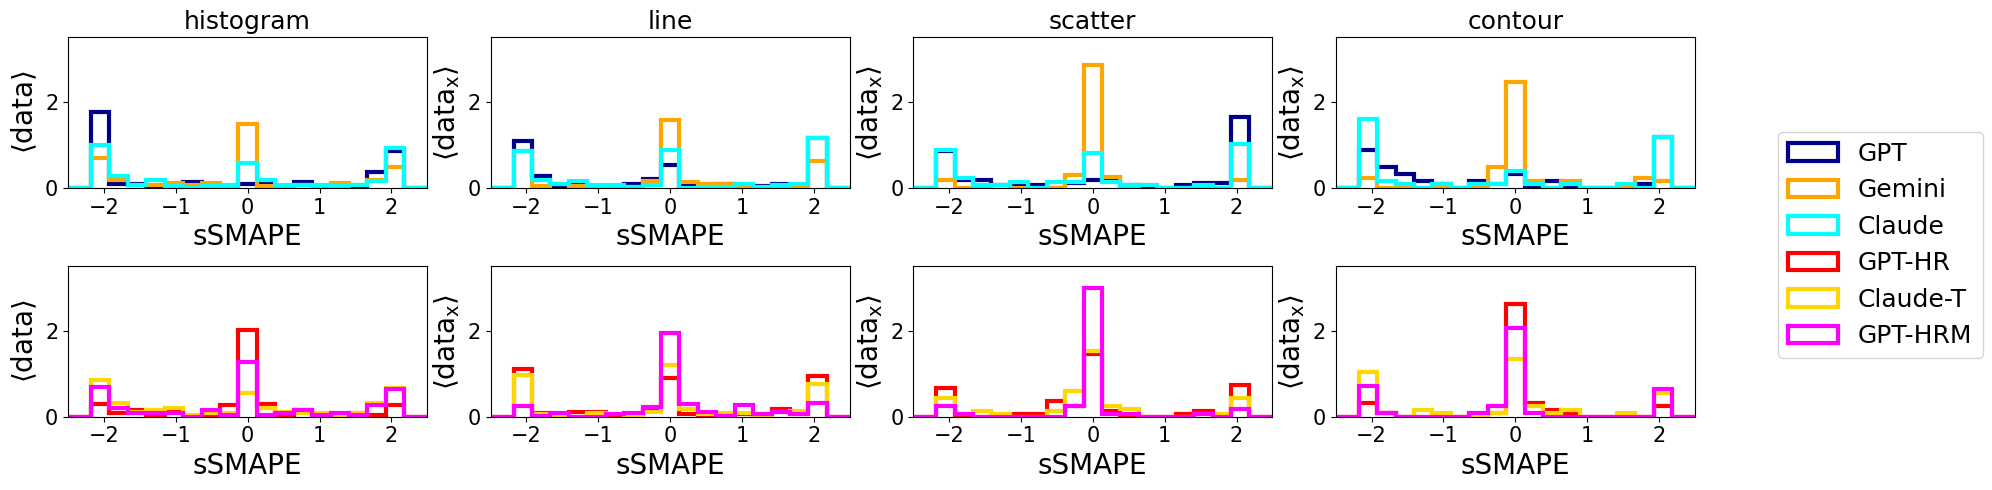

In [177]:
base = 5


fig, axes = plt.subplots(2, len(plot_types), figsize = (base*len(plot_types), base))

# label_others = r'$\mathrm{\overline{data_x}}$'
# label_hist = r'$\mathrm{\overline{data}}$'

label_others = r'$\mathrm{\langle data_x \rangle}$'
label_hist = r'$\mathrm{\langle data \rangle}$'

q = {}
q['line'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['scatter'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['contour'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['histogram'] = {'tag':'mean data','question':'What is the mean value of the data in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_hist} # different!

#calculation = 'SMAPE'
calculation = 'sSMAPE' # directional SMAPE

#take_abs = False
hmin = -5
hmax = 5
nbins = 40
xlim = (-2.5, 2.5)
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3
fontsize = 20
tick_fontsize = 15
legend_fontsize = 18
title_fontsize = 18

ylim = (0,3.5)


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

dfsubsave = None
dfplotsave = None

printnans = ''

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    for iplot,ptype in enumerate(plot_types):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            if dfsubsave is None:
                dfsubsave = dfsub2.copy()
            else:
                dfsubsave = pd.concat([dfsubsave.copy(),dfsub2.copy()])
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmtag_adder = ''
            lmm, lmtag_adder = calc_type(gt, lmm1, calculation=calculation)
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm, 'LMM orig':lmm1})
            if dfplotsave is None:
                dfplotsave = pd.DataFrame({'GT':gt, 'Calc':lmm, 'LMM orig':lmm1, 'model':np.repeat(model,len(lmm1))})
            else:
                dfplotsave = pd.concat([dfplotsave.copy(), pd.DataFrame({'GT':gt, 
                                                                        'Calc':lmm, 'LMM orig':lmm1, 
                                                                        'model':np.repeat(model,len(lmm1))})])
            diff = dfplot[lmtag]
            # count NaNs
            printnans += '  the number of NaNs for model ' + model + ' = ' + str(len(lmm[np.isnan(lmm)])) +'\n'        
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], edgecolor=colors[model], 
                        linewidth=hist_thick, histtype='step')
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['label'],  fontsize=fontsize)
            axes[0][iplot].set_title(ptype, fontsize=title_fontsize)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.5))


# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.85)  # adjust this value based on legend width
# absadd = ''
# if not take_abs:
#     absadd += '_noabs'
fig.savefig(save_fig_dir + 'mean_per_model_type_x_ssmape'+absadd+'.pdf')

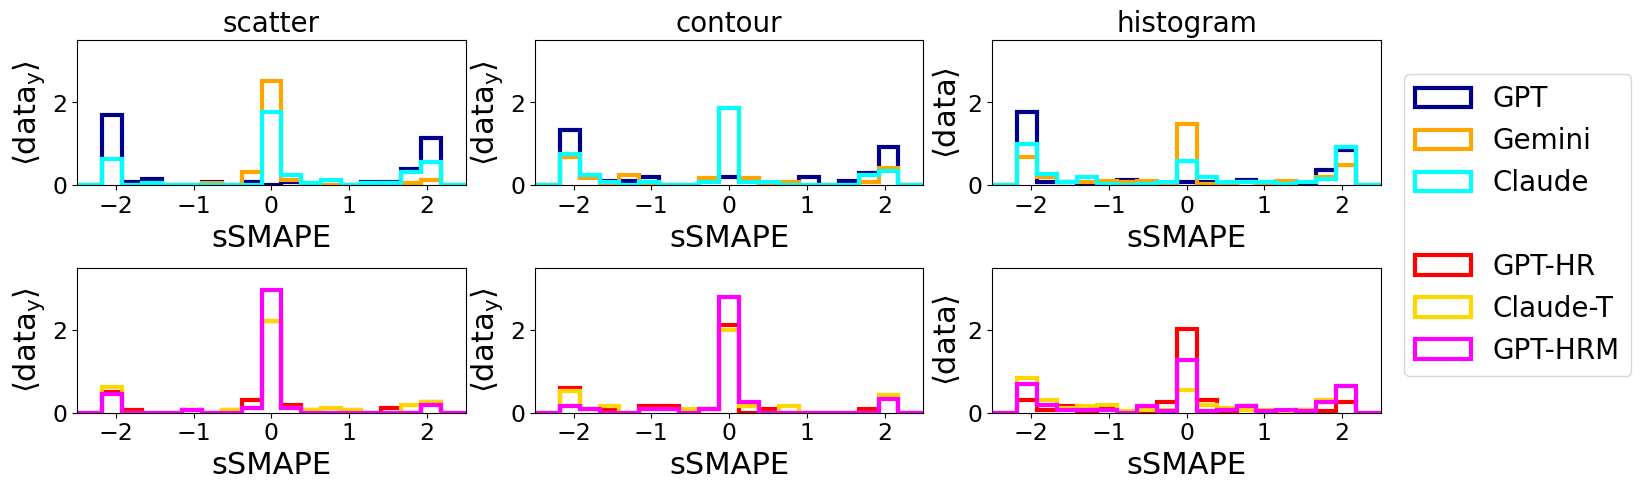

In [198]:
base = 5



# label_others = r'$\mathrm{\overline{data_x}}$'
# label_hist = r'$\mathrm{\overline{data}}$'

label_others = r'$\mathrm{\langle data_y \rangle}$'
label_hist = r'$\mathrm{\langle data \rangle}$'

q = {}
#q['line'] = {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['scatter'] = {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['contour'] = {'tag':'y-mean data','question':'What is the mean value of the data along the y-axis in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_others} 
q['histogram'] = {'tag':'mean data','question':'What is the mean value of the data in this figure panel?', 'type':'float',  'norm':'diff', 'label':label_hist} # different!

#calculation = 'SMAPE'
calculation = 'sSMAPE' # directional SMAPE

#take_abs = False
hmin = -5
hmax = 5
nbins = 40
xlim = (-2.5, 2.5)
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3

fontsize = 22
tick_fontsize = 17
legend_fontsize = 20
title_fontsize = 20

ylim = (0,3.5)

fac = 1.1
fig, axes = plt.subplots(2, len(list(q.keys())), figsize = (fac*base*len(list(q.keys())), base))


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

dfsubsave = None
dfplotsave = None

printnans = ''

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    #for iplot,ptype in enumerate(plot_types):
    for iplot,ptype in enumerate(list(q.keys())):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            if dfsubsave is None:
                dfsubsave = dfsub2.copy()
            else:
                dfsubsave = pd.concat([dfsubsave.copy(),dfsub2.copy()])
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmtag_adder = ''
            lmm, lmtag_adder = calc_type(gt, lmm1, calculation=calculation)
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm, 'LMM orig':lmm1})
            if dfplotsave is None:
                dfplotsave = pd.DataFrame({'GT':gt, 'Calc':lmm, 'LMM orig':lmm1, 'model':np.repeat(model,len(lmm1))})
            else:
                dfplotsave = pd.concat([dfplotsave.copy(), pd.DataFrame({'GT':gt, 
                                                                        'Calc':lmm, 'LMM orig':lmm1, 
                                                                        'model':np.repeat(model,len(lmm1))})])
            diff = dfplot[lmtag]
            # count NaNs
            printnans += '  the number of NaNs for model ' + model + ' = ' + str(len(lmm[np.isnan(lmm)])) +'\n'        
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], edgecolor=colors[model], 
                        linewidth=hist_thick, histtype='step')
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['label'],  fontsize=fontsize)
            axes[0][iplot].set_title(ptype, fontsize=title_fontsize)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

# fig.legend(all_handles, all_labels,
#            loc='center right',
#            fontsize=legend_fontsize,
#            bbox_to_anchor=(1.0, 0.5))
# Insert a blank spacer after the 3rd entry
spacer_handle = Patch(visible=False)
spacer_label = ''

split_idx = 3
all_handles.insert(split_idx, spacer_handle)
all_labels.insert(split_idx, spacer_label)

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.54))

# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.84)  # adjust this value based on legend width
# absadd = ''
# if not take_abs:
#     absadd += '_noabs'
fig.savefig(save_fig_dir + 'mean_per_model_type_y_ssmape'+absadd+'.pdf')

In [179]:
df[(df['plot type']=='line') & (df['Level Type']=='Plot-level questions')]['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many lines are there in the specified figure panel?',
       'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?',
       'What is the functional relationship between the x and y values in this figure panel?',
       'What is the maximum value of the data along the x-axis in this figure panel?',
       'What is the mean value of the data along the x-axis in this figure panel?',
       'What is the median value of the data along the x-axis in this figure panel?',
       'What is the minimum value of the data along the x-axis in this figure panel?'],
      dtype=object)

In [180]:
print(printnans)

  the number of NaNs for model GPT = 14
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 0
  the number of NaNs for model GPT = 8
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 0
  the number of NaNs for model GPT = 16
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 1
  the number of NaNs for model GPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model GPT-HRM = 0
  the number of NaNs for model GPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model GPT-HRM = 0
  the number of NaNs for model GPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model GPT-HRM = 0



  the number of NaNs for model GPT = 16
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 1
  the number of NaNs for model GPT = 38
  the number of NaNs for model Gemini = 6
  the number of NaNs for model Claude = 17
  the number of NaNs for model GPT = 7
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 11
  the number of NaNs for model GPT = 11
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 4
  the number of NaNs for model GPT-HR = 0
  the number of NaNs for model Claude-T = 1
  the number of NaNs for model GPT-HRM = 0
  the number of NaNs for model GPT-HR = 30
  the number of NaNs for model Claude-T = 21
  the number of NaNs for model GPT-HRM = 17


/var/folders/1c/xcwp8_px05xg1_3xd9nn9qhm0000gn/T/ipykernel_25693/2538554160.py:24: RuntimeWarning: divide by zero encountered in log10
  calc[~mask] = -np.log10(np.abs(lmm[~mask]/gt[~mask]))


  the number of NaNs for model GPT-HR = 6
  the number of NaNs for model Claude-T = 23
  the number of NaNs for model GPT-HRM = 1
  the number of NaNs for model GPT-HR = 9
  the number of NaNs for model Claude-T = 4
  the number of NaNs for model GPT-HRM = 2


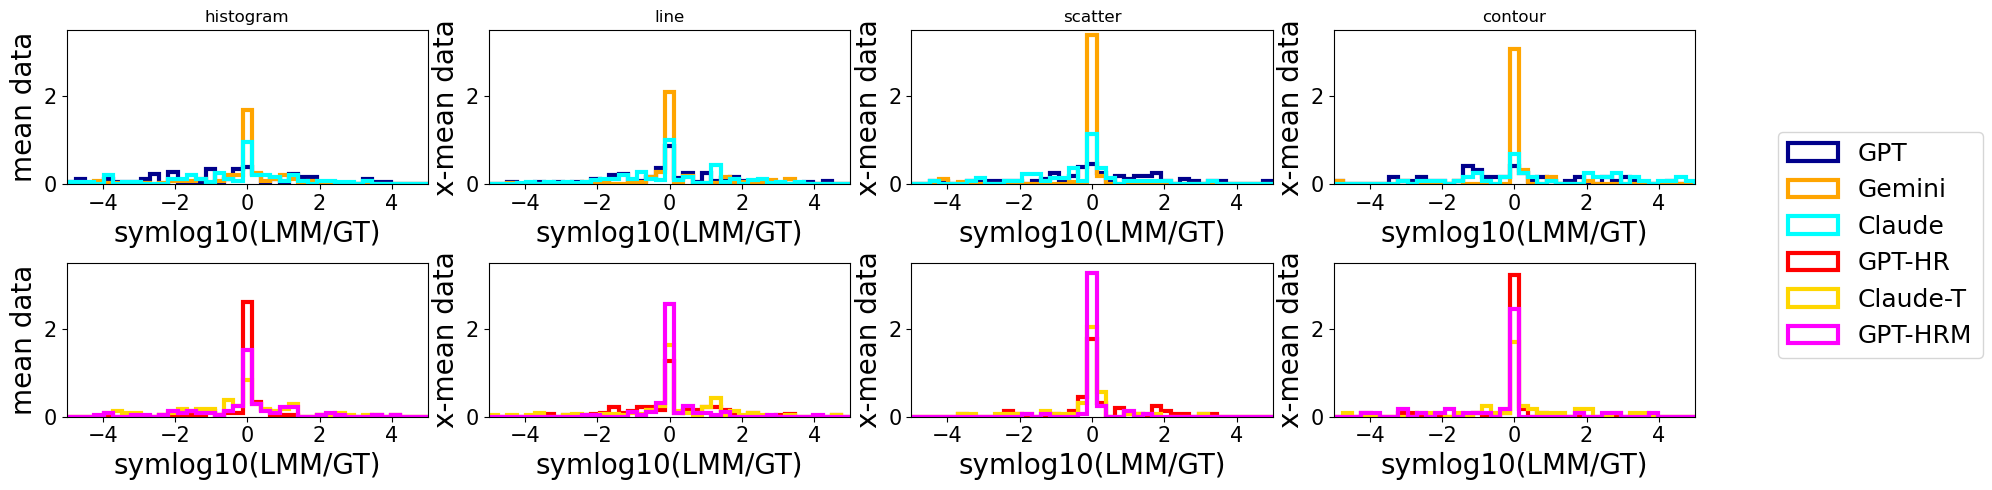

In [181]:
base = 5


fig, axes = plt.subplots(2, len(plot_types), figsize = (base*len(plot_types), base))

q = {}
q['line'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['scatter'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['contour'] = {'tag':'x-mean data','question':'What is the mean value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['histogram'] = {'tag':'mean data','question':'What is the mean value of the data in this figure panel?', 'type':'float',  'norm':'diff'} # different!

calculation = 'symlog' # directional SMAPE

#take_abs = False
hmin = -5
hmax = 5
nbins = 40
xlim = (-5, 5)
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3
fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

ylim = (0,3.5)


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

dfsubsave = None
dfplotsave = None

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    for iplot,ptype in enumerate(plot_types):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            if dfsubsave is None:
                dfsubsave = dfsub2.copy()
            else:
                dfsubsave = pd.concat([dfsubsave.copy(),dfsub2.copy()])
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmtag_adder = ''
            lmm, lmtag_adder = calc_type(gt, lmm1, calculation=calculation)
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm, 'LMM orig':lmm1})
            if dfplotsave is None:
                dfplotsave = pd.DataFrame({'GT':gt, 'Calc':lmm, 'LMM orig':lmm1, 'model':np.repeat(model,len(lmm1))})
            else:
                dfplotsave = pd.concat([dfplotsave.copy(), pd.DataFrame({'GT':gt, 
                                                                        'Calc':lmm, 'LMM orig':lmm1, 
                                                                        'model':np.repeat(model,len(lmm1))})])
            diff = dfplot[lmtag]
            # count NaNs
            print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))          
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], edgecolor=colors[model], 
                        linewidth=hist_thick, histtype='step')
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['tag'],  fontsize=fontsize)
            axes[0][iplot].set_title(ptype)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    # legend = ax.get_legend()
    # if legend is not None:
    #     # Set legend font size for second subplot
    #     ax.legend(fontsize=legend_fontsize)

# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.5))


# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.85)  # adjust this value based on legend width
absadd = ''
if not take_abs:
    absadd += '_noabs'
fig.savefig(save_fig_dir + 'mean_per_model_type_symlog'+absadd+'.pdf')

In [182]:
# look at specific points like around 0, and +/-2
zero_bins = [-0.25, 0.25]
print('************* ZERO BINS *****************')
for i,r in dfplotsave.iterrows():
    if not pd.isnull(r['Calc']):
        if r['Calc'] >= zero_bins[0] and r['Calc'] <= zero_bins[1]:
            print('Calc:', r['Calc'], ', GT:', r['GT'], ', LMM:', r['LMM orig'])

************* ZERO BINS *****************
Calc: -0.24816840122354492 , GT: 143.43443271180462 , LMM: 81.0
Calc: 0.018548907267612665 , GT: 38.279642782728295 , LMM: 39.95
Calc: -0.17354321866751451 , GT: 541.3147282999606 , LMM: 363.0
Calc: -0.015142315425474858 , GT: 54.56399147434343 , LMM: -56.5
Calc: 0.13576244941325158 , GT: 210.2589714718033 , LMM: 287.42
Calc: -0.09838861418207538 , GT: -25.085260181809467 , LMM: -20.0
Calc: 0.17787097336684268 , GT: 4.382005942470478 , LMM: 6.6
Calc: -0.053498154319616076 , GT: 70.41729980773778 , LMM: 62.256
Calc: -0.040608649855307016 , GT: 95.26273252034147 , LMM: -104.6
Calc: -0.02063079226237315 , GT: 2.8608195334690634 , LMM: -3.0
Calc: -0.011853008428499755 , GT: -61.790358773008236 , LMM: 63.5
Calc: 0.0076256184539241325 , GT: -63.868650246056866 , LMM: -65.0
Calc: -0.005677446764000101 , GT: -1114.4744896606765 , LMM: -1100.0
Calc: 0.006163534070396929 , GT: -39.43632683629375 , LMM: -40.0
Calc: 0.00518496791141665 , GT: 1.699587307003

In [183]:
# bin cut low -- looks like GT >> LMM
bin_cut_low = -1.75
print('************* LOW CUT *****************')
for i,r in dfplotsave.iterrows():
    if not pd.isnull(r['Calc']):
        if r['Calc'] <= bin_cut_low:
            print('Calc:', r['Calc'], ', GT:', r['GT'], ', LMM:', r['LMM orig'])

************* LOW CUT *****************
Calc: -2.043004384736917 , GT: 89.100044196083 , LMM: 0.807
Calc: -2.4626411858028248 , GT: 420735.5294716501 , LMM: 1450.0
Calc: -4.495814713430015 , GT: 30340.758169365836 , LMM: 0.96875
Calc: -9.331291858187722 , GT: 308569255114.18945 , LMM: 143.9
Calc: -3.745200662538584 , GT: 1390.4029201235778 , LMM: 0.25
Calc: -13.748883411246041 , GT: 2.008012619746861e+16 , LMM: 358.0
Calc: -2.613920418591057 , GT: 14140.95893731211 , LMM: 34.4
Calc: -2.0836197985148552 , GT: 484.9308234232053 , LMM: 4.0
Calc: -3.4991083729939247 , GT: -0.22874606327158478 , LMM: 721.875
Calc: -2.4604467425540983 , GT: -0.19570490258548973 , LMM: 56.5
Calc: -2.4497814594062017 , GT: 1690.1790325898914 , LMM: 6.0
Calc: -3.27246350368732 , GT: 6293.338763324039 , LMM: 3.3606060606060604
Calc: -7.581447499340438 , GT: 294.9205418207719 , LMM: -11249999999.999998
Calc: -1.982782376355736 , GT: 1.3292471202919642 , LMM: -127.758
Calc: -2.8373085956171122 , GT: 72227.84416443

In [184]:
# bin cut high -- looks like here GT << LMM
bin_cut_high = 1.75
print('************* HIGH CUT *****************')
for i,r in dfplotsave.iterrows():
    if not pd.isnull(r['Calc']):
        if r['Calc'] >= bin_cut_high:
            print('Calc:', r['Calc'], ', GT:', r['GT'], ', LMM:', r['LMM orig'])

************* HIGH CUT *****************
Calc: 3.4206453707837396 , GT: 3.0641148317261666 , LMM: 8071.428571428572
Calc: inf , GT: 4.561426392275432 , LMM: 0.0
Calc: 7.054794117114607 , GT: 11.344728767142355 , LMM: -1.0000000000000002e-06
Calc: 3.6636826663878583 , GT: 10.113403495953683 , LMM: 46620.83
Calc: 12.565993290865304 , GT: -0.307751067681138 , LMM: 8.36e-14
Calc: 2.3530513670508437 , GT: 0.6133494833977563 , LMM: 138.28
Calc: inf , GT: -137304.0631842925 , LMM: -0.0
Calc: inf , GT: 38.26389296470555 , LMM: 0.0
Calc: 7.397725020829912 , GT: 49975254735.279724 , LMM: -2000.0
Calc: inf , GT: -16.372737683369493 , LMM: 0.0
Calc: 3.9145500283904315 , GT: 328556.4668933006 , LMM: -40.0
Calc: inf , GT: 6.792909676169263 , LMM: 0.0
Calc: 3.2931648320929914 , GT: 157.12844734945892 , LMM: -0.08
Calc: inf , GT: 29194223993.003883 , LMM: 0.0
Calc: 13.138124822777241 , GT: 57.726351989716825 , LMM: -4.2e-12
Calc: inf , GT: 4.7320451239086 , LMM: 0.0
Calc: 1.9683685509084943 , GT: 1385

In [185]:
# Calc: -2.0 , GT: 18.59646140701447 , LMM: -9.5
#         calc = (lmm-gt)/((np.abs(lmm)+np.abs(gt))/2)
(-9.5 - 18.596)/((np.abs(-9.5)+np.abs(18.596))/2)

-2.0

In [186]:
(-9.5 - 18.596), (np.abs(-9.5)+np.abs(18.596))

(-28.096, 28.096)

In [187]:
for i,r in dfsubsave.iterrows():
    g = r['GT Answer']
    l = r['LMM Answer']
    key = list(g.keys())[0]
    g = g[key]; l = l[key]
    print(g, '|', l)

10.746404935298276 | 4.455
9174.515559505331 | 8071.428571428572
-63.868650246056866 | 81.0
-1.3013214496348688 | -1.0
-8.352361934707133 | 475.0
119.98585832284165 | 162.24000000000007
855749.1277505575 | None
86774192108.73294 | 0.807
6.256399888016575e+24 | 270.0
-580749.8726065463 | 1450.0
-1114.4744896606765 | -7.2
-39.43632683629375 | None
3.005878258921811 | 39.95
1.6995873070035137 | 0.96875
-36.19368844523856 | None
5656.2030319162595 | None
8.99396753907835 | -1000.0
3.0641148317261666 | 363.0
143.43443271180462 | 143.9
0.35559529826275604 | 0.25
-47.36967787786966 | -56.5
3.0784866419555557 | 0.0
89.100044196083 | None
-23.38358852913349 | None
420735.5294716501 | 358.0
-34.3020755891072 | 34.4
38.279642782728295 | -1.0000000000000002e-06
30340.758169365836 | 46620.83
34.715210956982176 | 1.01
541.3147282999606 | 55.0
308569255114.18945 | 1633.3333333333
1390.4029201235778 | None
54.56399147434343 | 4.0
4.561426392275432 | None
2.008012619746861e+16 | 287.42
14140.9589373121

In [188]:
dfplot['x-mean data GT'].min(), dfplot['x-mean data GT'].max()

(-2833963.486778131, 4467178669970.445)

(0.0, 100.0)

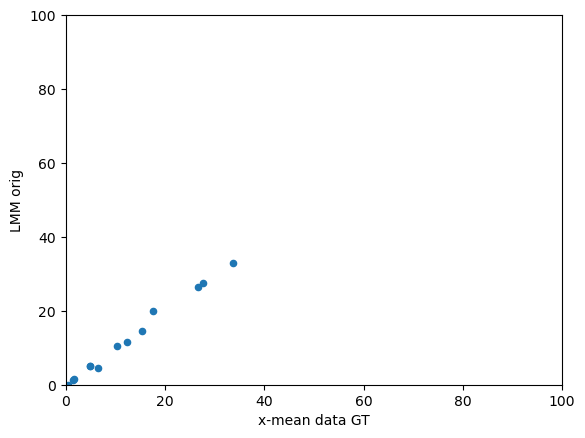

In [189]:
ax = dfplot.plot(x='x-mean data GT', y='LMM orig', kind='scatter')
ax.set_ylim(0,100)
ax.set_xlim(0,100)

In [190]:
len(dfsub2), len(dfplot)

(41, 51)

## Also try with median

  the number of NaNs for model GPT = 1
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 1
  the number of NaNs for model GPT = 11
  the number of NaNs for model Gemini = 44
  the number of NaNs for model Claude = 13
  the number of NaNs for model GPT = 0
  the number of NaNs for model Gemini = 0
  the number of NaNs for model Claude = 11
  the number of NaNs for model GPT = 1
  the number of NaNs for model Gemini = 1
  the number of NaNs for model Claude = 5
  the number of NaNs for model GPT-HR = 0
  the number of NaNs for model Claude-T = 0
  the number of NaNs for model GPT-HRM = 0
  the number of NaNs for model GPT-HR = 15
  the number of NaNs for model Claude-T = 43
  the number of NaNs for model GPT-HRM = 50
  the number of NaNs for model GPT-HR = 3
  the number of NaNs for model Claude-T = 2
  the number of NaNs for model GPT-HRM = 2
  the number of NaNs for model GPT-HR = 2
  the number of NaNs for model Claude-T = 1
  the number of NaNs for mod

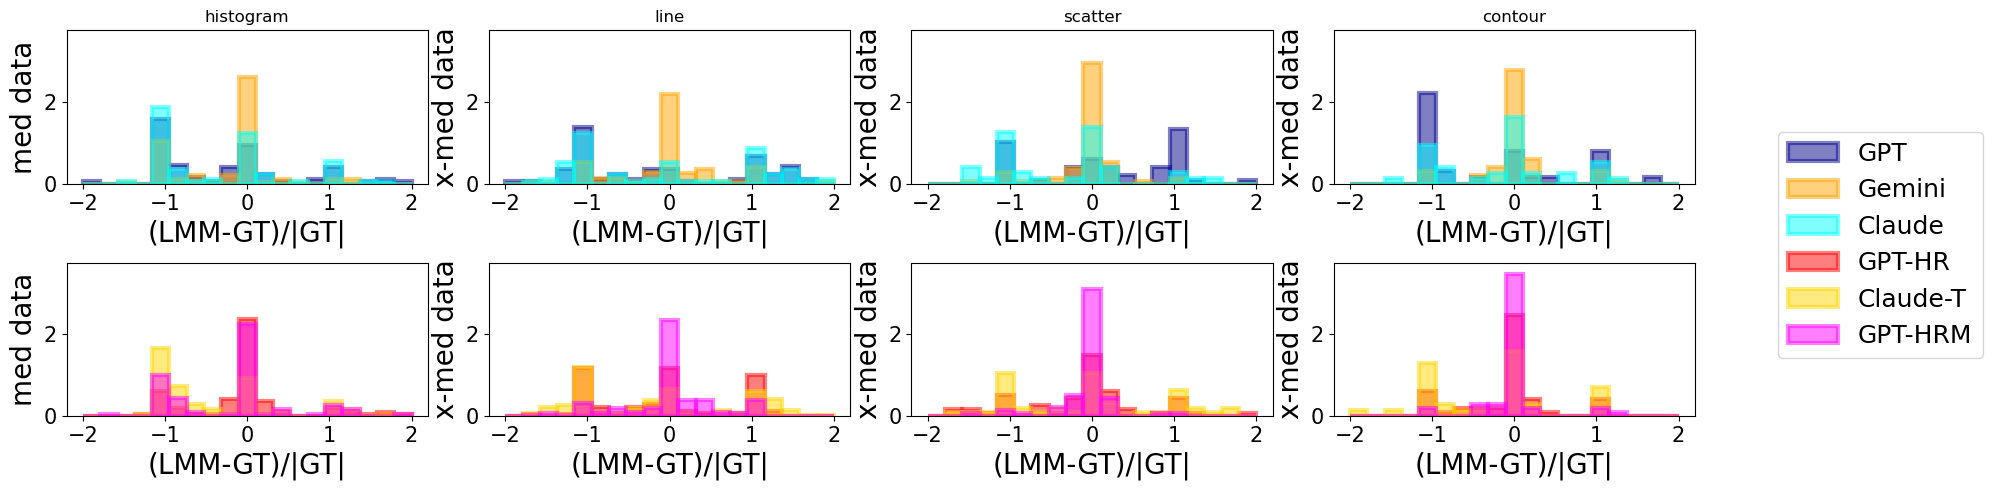

In [191]:
base = 5


fig, axes = plt.subplots(2, len(plot_types), figsize = (base*len(plot_types), base))

q = {}
q['line'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['scatter'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['contour'] = {'tag':'x-med data','question':'What is the median value of the data along the x-axis in this figure panel?', 'type':'float',  'norm':'diff'} 
q['histogram'] = {'tag':'med data','question':'What is the median value of the data in this figure panel?', 'type':'float',  'norm':'diff'} # different!

take_abs = True
hmin = -2
hmax = 2
nbins = 20
hist_bins = np.linspace(hmin,hmax,nbins)
alpha_hist = 0.5
hist_thick = 3
fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

ylim = (0,3.75)


# At the top, before the loop, initialize collectors
legend_handles = {}
legend_labels_map = {}

for imodeltype,(modeltypes,labels,colors) in enumerate(zip([low_dirs_to_use,midHigh_dirs_to_use],
                                                        [labels_low,labels_high],
                                                        [colors_low,colors_high])):
    #hasHistLegend = False

    for iplot,ptype in enumerate(plot_types):

        model_names = []
        for k,v in replace_names.items():
            if k + '/' in modeltypes:
                model_names.append(v)
        #print(model_names)
        dfsub = df[(df['model'].isin(model_names)) & (df['plot type']==ptype) & (df['question']==q[ptype]['question'])]
        for imodel, model in enumerate(dfsub['model'].unique()):
            dfsub2 = dfsub[dfsub['model']==model]
            gt, lmm1 = get_lmm_gt(dfsub2, q[ptype]['type'],verbose=False)
            gttag = q[ptype]['tag']+' GT'
            lmtag = labels[model]
            lmm = deepcopy(lmm1)
            lmtag_adder = ''
            diffnorm = False
            if 'norm' in q[ptype]:
                if 'diff':
                    if take_abs:
                        lmm = (lmm-gt)/np.abs(gt)
                        lmtag_adder = '(LMM-GT)/|GT|'
                    else:
                        lmm = (lmm-gt)/gt
                        lmtag_adder = '(LMM-GT)/GT'

                    diffnorm = True
            dfplot = pd.DataFrame({gttag:gt, lmtag:lmm, 'lmm orig':lmm1})
            diff = dfplot[lmtag]
            # count NaNs
            print('  the number of NaNs for model', model, '=', len(lmm[np.isnan(lmm)]))
            axes[imodeltype][iplot].hist(diff, density=True, bins=hist_bins, label=labels[model], 
                        color=colors[model], alpha=alpha_hist, edgecolor=colors[model], 
                        linewidth=hist_thick)
            axes[imodeltype][iplot].set_xlabel(lmtag_adder, fontsize=fontsize)
            axes[imodeltype][iplot].set_ylabel(q[ptype]['tag'],  fontsize=fontsize)
            if not hasHistLegend:
                axes[imodeltype][iplot].legend()
                #hasHistLegend = True
            axes[0][iplot].set_title(ptype)
            # Inside the inner loop, replace the legend block with:
            # (remove the hasHistLegend logic entirely)
            h, l = axes[imodeltype][iplot].get_legend_handles_labels()
            for handle, label in zip(h, l):
                if label not in legend_labels_map:
                    legend_handles[label] = handle
                    legend_labels_map[label] = label

# set font sizes
for ax in axes.flatten():
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    ax.set_ylim(ylim)
    # legend = ax.get_legend()
    # if legend is not None:
    #     # Set legend font size for second subplot
    #     ax.legend(fontsize=legend_fontsize)

# Remove any per-axis legends that may have been set
for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# Build ordered handles/labels
all_handles = list(legend_handles.values())
all_labels = list(legend_labels_map.keys())

fig.legend(all_handles, all_labels,
           loc='center right',
           fontsize=legend_fontsize,
           bbox_to_anchor=(1.0, 0.5))


# Make room for the legend on the right
fig.tight_layout()
fig.subplots_adjust(right=0.85)  # adjust this value based on legend width

fig.savefig(save_fig_dir + 'median_per_model_type.pdf')

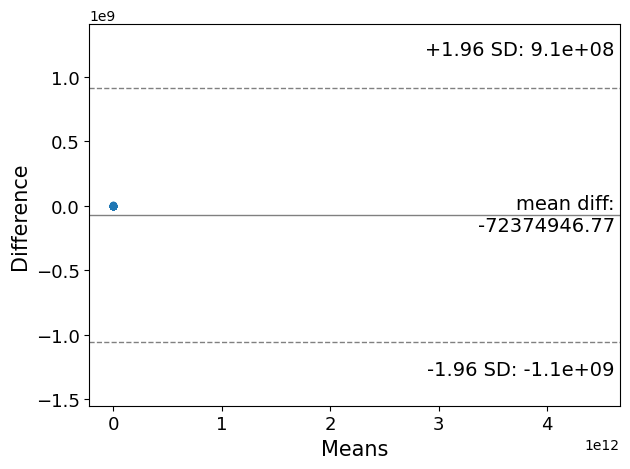

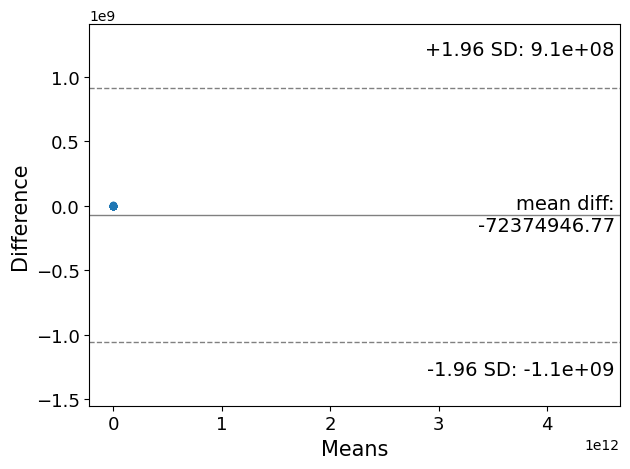

In [192]:
sm.graphics.mean_diff_plot(dfplot['x-med data GT'], dfplot['lmm orig'])


In [193]:
dfplot

,x-med data GT,GPT-HRM,lmm orig
0,-2.968720e+05,-0.010537,-3.000000e+05
1,1.475014e+01,-0.220346,1.150000e+01
2,6.362924e+00,-0.371358,4.000000e+00
3,6.518059e+00,-0.386320,4.000000e+00
4,4.468297e+02,-0.026475,4.350000e+02
5,4.321734e+02,0.006540,4.350000e+02
6,4.414340e+02,-0.014575,4.350000e+02
7,4.535438e+02,-0.040887,4.350000e+02
8,4.421778e+02,-0.016233,4.350000e+02
9,4.514331e+02,-0.036402,4.350000e+02


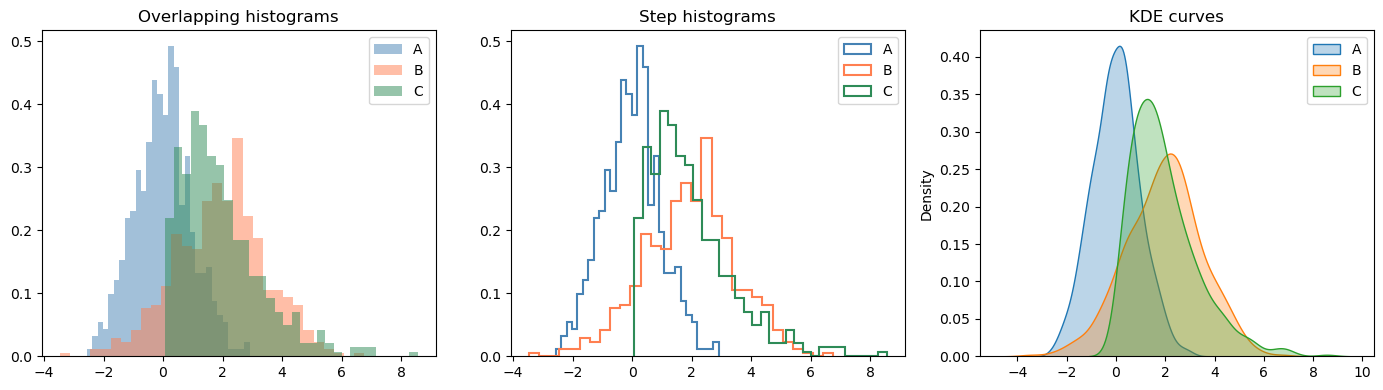

In [194]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(42)
a = rng.normal(0, 1, 500)
b = rng.normal(2, 1.5, 500)
c = rng.gamma(2, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Option 1: Overlapping histograms with alpha ---
ax = axes[0]
for data, label, color in zip([a, b, c], ['A', 'B', 'C'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(data, bins=30, alpha=0.5, label=label, color=color, density=True)
ax.set_title('Overlapping histograms')
ax.legend()

# --- Option 2: Step histograms ---
ax = axes[1]
for data, label, color in zip([a, b, c], ['A', 'B', 'C'], ['steelblue', 'coral', 'seagreen']):
    ax.hist(data, bins=30, histtype='step', label=label, color=color, density=True, linewidth=1.5)
ax.set_title('Step histograms')
ax.legend()

# --- Option 3: KDE curves ---
ax = axes[2]
for data, label in zip([a, b, c], ['A', 'B', 'C']):
    sns.kdeplot(data, ax=ax, label=label, fill=True, alpha=0.3)
ax.set_title('KDE curves')
ax.legend()

plt.tight_layout()
plt.show()

## Basic examples of metric

In [195]:
calcs = [
    {'gt':5, 'lmm':0},
    {'gt':5, 'lmm':-5},
    {'gt':5, 'lmm':5},
    {'gt':5, 'lmm':2.5},
    {'gt':5, 'lmm':-2.5}, 
    {'gt':0.001, 'lmm':0},
    {'gt':0.001, 'lmm':-5},
    {'gt':0.001, 'lmm':5},
    {'gt':0.001, 'lmm':2.5},
    {'gt':0.001, 'lmm':-2.5}
]


for calc in calcs:
    m = (calc['lmm']-calc['gt'])/calc['gt']
    print('GT =', calc['gt'], ', LMM =', calc['lmm'])
    print( '  (LMM-GT)/GT =', m)
    m2 = (calc['lmm']-calc['gt'])/np.abs(calc['gt'])
    print('  (LMM-GT)/|GT| =', m2)
    print('')


GT = 5 , LMM = 0
  (LMM-GT)/GT = -1.0
  (LMM-GT)/|GT| = -1.0

GT = 5 , LMM = -5
  (LMM-GT)/GT = -2.0
  (LMM-GT)/|GT| = -2.0

GT = 5 , LMM = 5
  (LMM-GT)/GT = 0.0
  (LMM-GT)/|GT| = 0.0

GT = 5 , LMM = 2.5
  (LMM-GT)/GT = -0.5
  (LMM-GT)/|GT| = -0.5

GT = 5 , LMM = -2.5
  (LMM-GT)/GT = -1.5
  (LMM-GT)/|GT| = -1.5

GT = 0.001 , LMM = 0
  (LMM-GT)/GT = -1.0
  (LMM-GT)/|GT| = -1.0

GT = 0.001 , LMM = -5
  (LMM-GT)/GT = -5001.0
  (LMM-GT)/|GT| = -5001.0

GT = 0.001 , LMM = 5
  (LMM-GT)/GT = 4999.0
  (LMM-GT)/|GT| = 4999.0

GT = 0.001 , LMM = 2.5
  (LMM-GT)/GT = 2499.0
  (LMM-GT)/|GT| = 2499.0

GT = 0.001 , LMM = -2.5
  (LMM-GT)/GT = -2501.0
  (LMM-GT)/|GT| = -2501.0



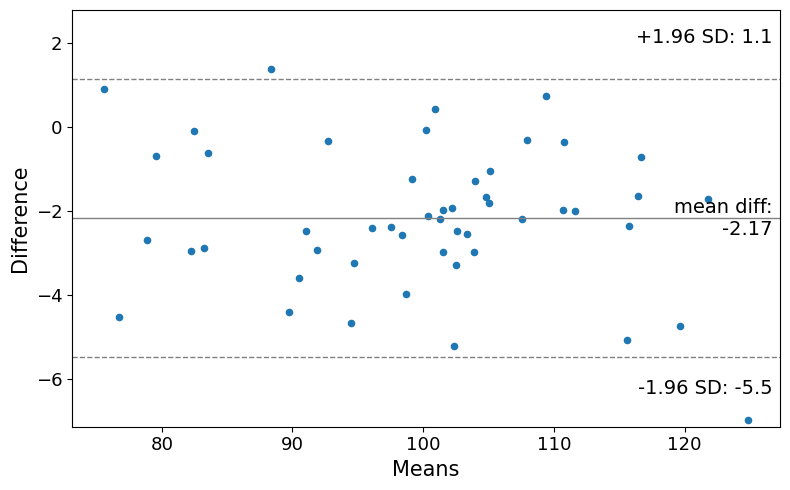

In [196]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Sample data
method1 = np.random.normal(100, 10, 50)
method2 = method1 + np.random.normal(2, 2, 50) # Added bias and noise

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))
sm.graphics.mean_diff_plot(method1, method2, ax=ax)

plt.show()